# Synthetic DAG - 12 nodes

In [15]:
import numpy as np
import networkx as nx
import pandas as pd
import random

def generate_random_dag(num_nodes=12, edge_prob=0.2, seed=42):
    random.seed(seed)
    np.random.seed(seed)
    G = nx.DiGraph()
    G.add_nodes_from(range(num_nodes))
    for i in range(num_nodes):
        for j in range(i+1, num_nodes):
            if random.random() < edge_prob:
                G.add_edge(i, j)
    assert nx.is_directed_acyclic_graph(G)
    return G

def simulate_linear_sem(G, n_samples=1000):
    num_nodes = len(G.nodes)
    data = np.zeros((n_samples, num_nodes))
    ordering = list(nx.topological_sort(G))

    for node in ordering:
        parents = list(G.predecessors(node))
        if parents:
            weights = np.random.uniform(0.5, 2.0, len(parents))
            data[:, node] = data[:, parents] @ weights + np.random.laplace(size=n_samples)
        else:
            data[:, node] = np.random.laplace(size=n_samples)
    return data

# Generate and save
G = generate_random_dag(num_nodes=12, edge_prob=0.3)
data = simulate_linear_sem(G)
df = pd.DataFrame(data, columns=[f"X{i}" for i in range(data.shape[1])])
df.to_csv("synthetic_dag_data.csv", index=False)

print("Generated DAG with nodes:", G.nodes)
print("Edges:", G.edges)

Generated DAG with nodes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
Edges: [(0, 2), (0, 3), (0, 4), (0, 8), (0, 10), (0, 11), (1, 3), (1, 4), (1, 7), (1, 10), (2, 5), (2, 8), (2, 9), (4, 8), (4, 9), (4, 10), (4, 11), (5, 6), (5, 7), (5, 8), (6, 7), (6, 8), (7, 8), (7, 10)]


In [16]:
!pip install causal-learn

## run ConstraintPC

In [17]:
from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.cit import CIT
from causallearn.utils.GraphUtils import GraphUtils
from PIL import Image
import io

# load data
data = pd.read_csv("synthetic_dag_data.csv").values
indep_test = CIT(data, data_type='continuous')
pc_graph = pc(data, indep_test_func=indep_test, alpha=0.05)

# visualize the graph
dot = GraphUtils.to_pydot(pc_graph.G, labels=[f"X{i}" for i in range(data.shape[1])])
image = Image.open(io.BytesIO(dot.create_png()))
image.save("pc_synthetic.png")
image.show()

  0%|          | 0/12 [00:00<?, ?it/s]

## run LiNGAM

In [4]:
!pip install lingam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 22.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 522.0/522.0 kB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 68.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.2/100.2 kB 9.2 MB/s eta 0:00:00
  Created wheel for semopy: filename=semopy-2.3.11-py3-none-any.whl size=1659682 sha256=180e73cbba4e5d8e12a3ebe2c0caa422371167fba9e0cd5098f2c416539f4499
  Stored in directory: /root/.cache/pip/wheels/d2/9a/31/fae291ff6a649bad125037eef8c7cc63d8c542e14bdcccea37
Successfully built semopy
  Attempting uninstall: numpy
    F

In [18]:
import pandas as pd

In [19]:
from lingam import DirectLiNGAM

model = DirectLiNGAM()
data = pd.read_csv("synthetic_dag_data.csv").values
model.fit(data)
adj_matrix = (model.adjacency_matrix_ != 0).astype(int)

print("Estimated adjacency matrix (LiNGAM):")
print(adj_matrix)

Estimated adjacency matrix (LiNGAM):
[[0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0]
 [1 1 0 0 0 0 0 0 0 0 0 0]
 [1 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0 0 0]
 [0 1 0 0 0 1 1 0 0 0 0 0]
 [1 0 1 0 1 1 1 1 0 0 0 0]
 [0 0 1 0 1 0 0 0 0 0 0 0]
 [1 1 0 0 1 0 0 1 0 0 0 0]
 [1 0 1 0 1 0 0 0 0 0 0 0]]


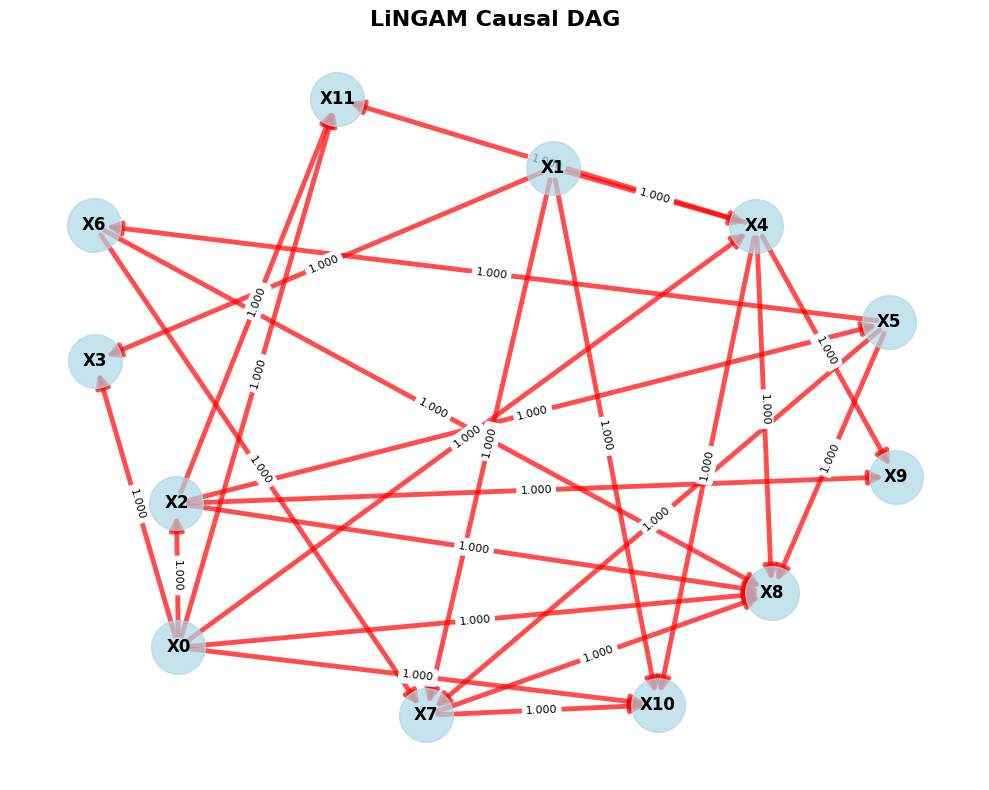

In [20]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

def create_lingam_dag(lingam_adj, data):
    G = nx.DiGraph()
    n_nodes = lingam_adj.shape[0] # add nodes
    node_labels = [f"X{i}" for i in range(n_nodes)]
    G.add_nodes_from(range(n_nodes))
    # LiNGAM adjacency matrix: A[i,j] != 0 means edge from j to i
    for i in range(n_nodes):
        for j in range(n_nodes):
            if abs(lingam_adj[i, j]) > 1e-6:
                G.add_edge(j, i, weight=lingam_adj[i, j])

    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(G, k=3, iterations=50)
    nx.draw_networkx_nodes(G, pos, node_color='lightblue',
                          node_size=1500, alpha=0.7) # nodes

    edges = G.edges() # edges
    weights = [G[u][v]['weight'] for u, v in edges]

    if weights:
        max_weight = max(abs(w) for w in weights)
        colors = ['red' if w > 0 else 'blue' for w in weights]
        widths = [abs(w) / max_weight * 3 + 0.5 for w in weights]
    else:
        colors = []
        widths = []

    nx.draw_networkx_edges(G, pos, edge_color=colors, width=widths,
                          alpha=0.7, arrows=True, arrowsize=20)

    # draw labels
    labels = {i: node_labels[i] for i in range(n_nodes)}
    nx.draw_networkx_labels(G, pos, labels, font_size=12, font_weight='bold')

    # add edge labels (weights)
    edge_labels = {(u, v): f"{G[u][v]['weight']:.3f}"
                   for u, v in G.edges() if abs(G[u][v]['weight']) > 0.1}
    nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=8)

    plt.title("LiNGAM Causal DAG", fontsize=16, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.savefig("lingam_synthetic.png", dpi=300, bbox_inches='tight')
    plt.show()

    return G

lingam_graph = create_lingam_dag(adj_matrix, data)

In [21]:
def dag_to_adj_matrix(G, node_order):
    n = len(node_order)
    idx_map = {node: i for i, node in enumerate(node_order)}
    adj = np.zeros((n, n), dtype=int)
    for u, v in G.edges():
        adj[idx_map[u], idx_map[v]] = 1
    return adj

In [22]:
def evaluate_graph(true_adj, est_adj):
    assert true_adj.shape == est_adj.shape
    diff = np.abs(true_adj - est_adj)

    shd = np.sum(diff)

    true_edges = (true_adj != 0).astype(int)
    est_edges = (est_adj != 0).astype(int)

    tp = np.sum(true_edges * est_edges)
    fp = np.sum((1 - true_edges) * est_edges)
    fn = np.sum(true_edges * (1 - est_edges))

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    return {
        'SHD': shd,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'TP': tp,
        'FP': fp,
        'FN': fn
    }


#### PC with ground truth

In [23]:
import numpy as np
from causallearn.utils.GraphUtils import GraphUtils

# convert NetworkX DAG to adjacency matrix (your original code - this part is correct)
true_adj = dag_to_adj_matrix(G, node_order=list(range(len(G.nodes))))

pc_adj_matrix = pc_graph.G.graph
#pc_adj_matrix = np.array(pc_graph.G.graph)

# Evaluate the results
results_pc = evaluate_graph(true_adj, pc_adj_matrix)
print("\n=== PC Algorithm Results ===")
for k, v in results_pc.items():
    print(f"{k}: {v}")

# Optional: Print matrix shapes to verify compatibility
print(f"\nTrue adjacency matrix shape: {true_adj.shape}")
print(f"PC adjacency matrix shape: {pc_adj_matrix.shape}")


=== PC Algorithm Results ===
SHD: 46
Precision: 0.43333333333333335
Recall: 0.5416666666666666
F1: 0.4814814814814815
TP: 13
FP: 17
FN: 11

True adjacency matrix shape: (12, 12)
PC adjacency matrix shape: (12, 12)


In [24]:
lingam_adj = (model.adjacency_matrix_ != 0).astype(int)
results_lingam = evaluate_graph(true_adj, lingam_adj)

print("\n=== LiNGAM Results ===")
for k, v in results_lingam.items():
    print(f"{k}: {v}")


=== LiNGAM Results ===
SHD: 49
Precision: 0.0
Recall: 0.0
F1: 0
TP: 0
FP: 25
FN: 24


# synthetic DAG - 30 nodes

In [7]:
import numpy as np
import networkx as nx
import pandas as pd
import random

def generate_random_dag(num_nodes=30, edge_prob=0.2, seed=42):
    random.seed(seed)
    np.random.seed(seed)
    G = nx.DiGraph()
    G.add_nodes_from(range(num_nodes))
    for i in range(num_nodes):
        for j in range(i+1, num_nodes):
            if random.random() < edge_prob:
                G.add_edge(i, j)
    assert nx.is_directed_acyclic_graph(G)
    return G

def simulate_linear_sem(G, n_samples=1000):
    num_nodes = len(G.nodes)
    data = np.zeros((n_samples, num_nodes))
    ordering = list(nx.topological_sort(G))

    for node in ordering:
        parents = list(G.predecessors(node))
        if parents:
            weights = np.random.uniform(0.5, 2.0, len(parents))
            data[:, node] = data[:, parents] @ weights + np.random.laplace(size=n_samples)
        else:
            data[:, node] = np.random.laplace(size=n_samples)
    return data

# Generate and save
G = generate_random_dag(num_nodes=30, edge_prob=0.3)
data = simulate_linear_sem(G)
df = pd.DataFrame(data, columns=[f"X{i}" for i in range(data.shape[1])])
df.to_csv("synthetic_dag_data.csv", index=False)

print("Generated DAG with nodes:", G.nodes)
print("Edges:", G.edges)

Generated DAG with nodes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]
Edges: [(0, 2), (0, 3), (0, 4), (0, 8), (0, 10), (0, 11), (0, 13), (0, 14), (0, 17), (0, 20), (0, 24), (0, 27), (0, 28), (1, 14), (1, 15), (1, 16), (1, 17), (1, 18), (1, 19), (1, 20), (1, 24), (1, 25), (1, 29), (2, 4), (2, 12), (2, 13), (2, 15), (2, 16), (2, 24), (2, 25), (2, 27), (3, 5), (3, 8), (3, 9), (3, 10), (3, 14), (3, 20), (3, 24), (3, 26), (4, 6), (4, 8), (4, 11), (4, 14), (4, 19), (4, 21), (4, 26), (4, 29), (5, 7), (5, 10), (5, 13), (5, 16), (5, 19), (5, 25), (5, 26), (5, 29), (6, 7), (6, 8), (6, 10), (6, 13), (6, 14), (6, 16), (6, 17), (6, 23), (6, 24), (7, 9), (7, 13), (7, 14), (7, 17), (7, 18), (7, 23), (7, 29), (8, 10), (8, 12), (8, 15), (8, 23), (8, 24), (8, 29), (9, 13), (9, 15), (9, 16), (9, 19), (9, 20), (9, 22), (9, 29), (10, 12), (10, 15), (10, 18), (10, 22), (10, 23), (10, 24), (10, 29), (11, 17), (11, 19), (11, 22), (11, 23), (11

### ConstraintPC

In [8]:
from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.cit import CIT
from causallearn.utils.GraphUtils import GraphUtils
from PIL import Image
import io

# load data
data = pd.read_csv("synthetic_dag_data.csv").values
indep_test = CIT(data, data_type='continuous')
pc_graph = pc(data, indep_test_func=indep_test, alpha=0.05)

# visualize the graph
dot = GraphUtils.to_pydot(pc_graph.G, labels=[f"X{i}" for i in range(data.shape[1])])
image = Image.open(io.BytesIO(dot.create_png()))
image.save("pc_synthetic.png")
image.show()

  0%|          | 0/30 [00:00<?, ?it/s]

In [9]:
import pandas as pd
from lingam import DirectLiNGAM

model = DirectLiNGAM()
data = pd.read_csv("synthetic_dag_data.csv").values
model.fit(data)
adj_matrix = (model.adjacency_matrix_ != 0).astype(int)

print("Estimated adjacency matrix (LiNGAM):")
print(adj_matrix)

Estimated adjacency matrix (LiNGAM):
[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 1 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 1 0 1 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 1 0 0 1 1 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 1 0 1 1 0 1 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 1 1 0 0 0 0 0 

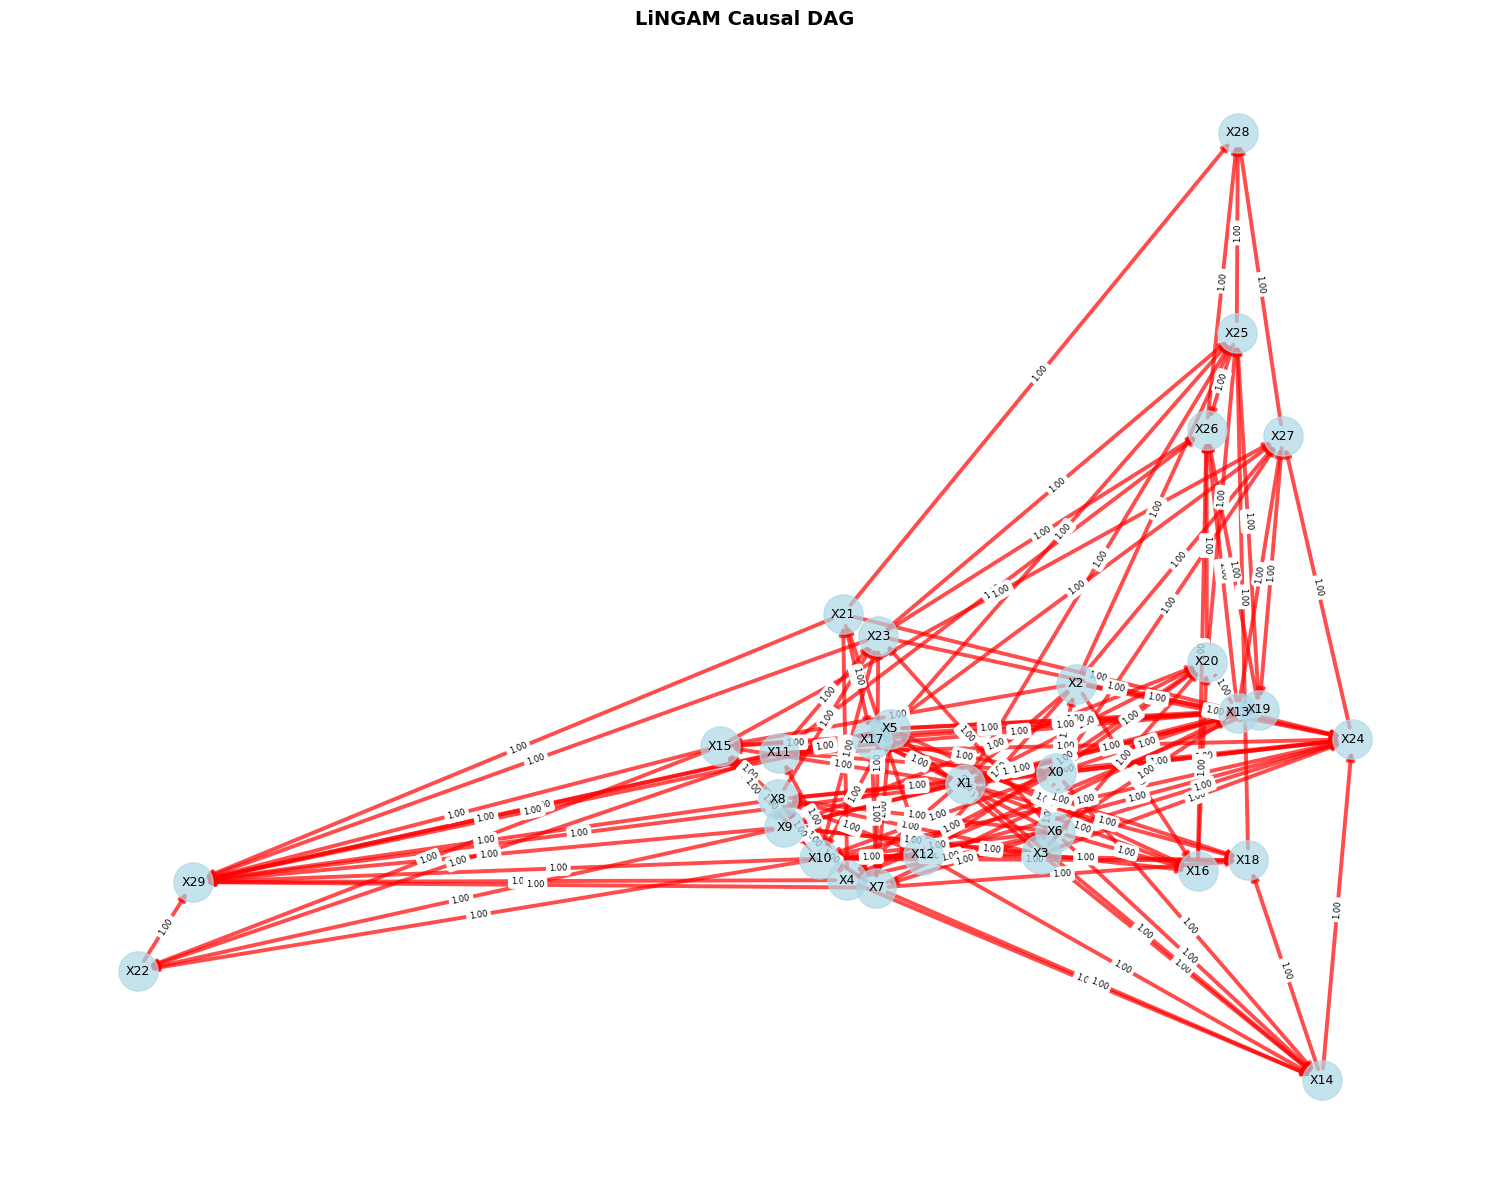

In [10]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

def create_lingam_dag(lingam_adj, data):
    G = nx.DiGraph()
    n_nodes = lingam_adj.shape[0]  # Number of nodes
    node_labels = [f"X{i}" for i in range(n_nodes)]
    G.add_nodes_from(range(n_nodes))

    # Add edges from LiNGAM adjacency matrix (A[i,j] != 0 means edge j → i)
    for i in range(n_nodes):
        for j in range(n_nodes):
            if abs(lingam_adj[i, j]) > 1e-6:
                G.add_edge(j, i, weight=lingam_adj[i, j])

    # Adjust plot size and layout params for larger graphs
    plt.figure(figsize=(15, 12))
    pos = nx.spring_layout(G, k=1.5/np.sqrt(n_nodes), iterations=100)

    nx.draw_networkx_nodes(G, pos, node_color='lightblue',
                           node_size=800, alpha=0.7)

    edges = G.edges()
    weights = [G[u][v]['weight'] for u, v in edges]

    if weights:
        max_weight = max(abs(w) for w in weights)
        colors = ['red' if w > 0 else 'blue' for w in weights]
        widths = [abs(w) / max_weight * 2.5 + 0.3 for w in weights]
    else:
        colors = []
        widths = []

    nx.draw_networkx_edges(G, pos, edge_color=colors, width=widths,
                           alpha=0.7, arrows=True, arrowsize=10)

    labels = {i: node_labels[i] for i in range(n_nodes)}
    nx.draw_networkx_labels(G, pos, labels, font_size=9)

    edge_labels = {(u, v): f"{G[u][v]['weight']:.2f}"
                   for u, v in G.edges() if abs(G[u][v]['weight']) > 0.1}
    nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=6)

    plt.title("LiNGAM Causal DAG", fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.savefig("lingam_synthetic.png", dpi=300, bbox_inches='tight')
    plt.show()

    return G

lingam_graph = create_lingam_dag(adj_matrix, data)

In [11]:
def dag_to_adj_matrix(G, node_order):
    n = len(node_order)
    idx_map = {node: i for i, node in enumerate(node_order)}
    adj = np.zeros((n, n), dtype=int)
    for u, v in G.edges():
        adj[idx_map[u], idx_map[v]] = 1
    return adj

In [12]:
def evaluate_graph(true_adj, est_adj):
    assert true_adj.shape == est_adj.shape
    diff = np.abs(true_adj - est_adj)

    shd = np.sum(diff)

    true_edges = (true_adj != 0).astype(int)
    est_edges = (est_adj != 0).astype(int)

    tp = np.sum(true_edges * est_edges)
    fp = np.sum((1 - true_edges) * est_edges)
    fn = np.sum(true_edges * (1 - est_edges))

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    return {
        'SHD': shd,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'TP': tp,
        'FP': fp,
        'FN': fn
    }

In [13]:
# ConstraintPC
import numpy as np
from causallearn.utils.GraphUtils import GraphUtils

# convert NetworkX DAG to adjacency matrix (your original code - this part is correct)
true_adj = dag_to_adj_matrix(G, node_order=list(range(len(G.nodes))))

pc_adj_matrix = pc_graph.G.graph
#pc_adj_matrix = np.array(pc_graph.G.graph)

# Evaluate the results
results_pc = evaluate_graph(true_adj, pc_adj_matrix)
print("\n=== PC Algorithm Results ===")
for k, v in results_pc.items():
    print(f"{k}: {v}")

# Optional: Print matrix shapes to verify compatibility
print(f"\nTrue adjacency matrix shape: {true_adj.shape}")
print(f"PC adjacency matrix shape: {pc_adj_matrix.shape}")


=== PC Algorithm Results ===
SHD: 181
Precision: 0.391304347826087
Recall: 0.1258741258741259
F1: 0.1904761904761905
TP: 18
FP: 28
FN: 125

True adjacency matrix shape: (30, 30)
PC adjacency matrix shape: (30, 30)


In [14]:
lingam_adj = (model.adjacency_matrix_ != 0).astype(int)
results_lingam = evaluate_graph(true_adj, lingam_adj)

print("\n=== LiNGAM Results ===")
for k, v in results_lingam.items():
    print(f"{k}: {v}")


=== LiNGAM Results ===
SHD: 279
Precision: 0.0
Recall: 0.0
F1: 0
TP: 0
FP: 136
FN: 143
